<a href="https://colab.research.google.com/github/amarnathsujith/Insurance-Charge-Predictor/blob/main/Copy_of_Mini_Project_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from xgboost import XGBRegressor

In [2]:
from google.colab import files
uploaded = files.upload()
# This will prompt you to select 'insurance.csv' from your computer.

Saving insurance.csv to insurance.csv


In [3]:
from google.colab import files
files.upload()



Saving insurance.csv to insurance (1).csv


{'insurance (1).csv': b'age,sex,bmi,children,smoker,region,charges\r\n19,female,27.9,0,yes,southwest,16884.924\r\n18,male,33.77,1,no,southeast,1725.5523\r\n28,male,33,3,no,southeast,4449.462\r\n33,male,22.705,0,no,northwest,21984.47061\r\n32,male,28.88,0,no,northwest,3866.8552\r\n31,female,25.74,0,no,southeast,3756.6216\r\n46,female,33.44,1,no,southeast,8240.5896\r\n37,female,27.74,3,no,northwest,7281.5056\r\n37,male,29.83,2,no,northeast,6406.4107\r\n60,female,25.84,0,no,northwest,28923.13692\r\n25,male,26.22,0,no,northeast,2721.3208\r\n62,female,26.29,0,yes,southeast,27808.7251\r\n23,male,34.4,0,no,southwest,1826.843\r\n56,female,39.82,0,no,southeast,11090.7178\r\n27,male,42.13,0,yes,southeast,39611.7577\r\n19,male,24.6,1,no,southwest,1837.237\r\n52,female,30.78,1,no,northeast,10797.3362\r\n23,male,23.845,0,no,northeast,2395.17155\r\n56,male,40.3,0,no,southwest,10602.385\r\n30,male,35.3,0,yes,southwest,36837.467\r\n60,female,36.005,0,no,northeast,13228.84695\r\n30,female,32.4,1,no,sou

In [4]:
insurance_dataset=pd.read_csv('insurance.csv')



In [5]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
insurance_dataset.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [7]:
insurance_dataset.shape

(1338, 7)

In [8]:
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
#checking for misssing values
insurance_dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [11]:
insurance_dataset=insurance_dataset.dropna()

In [12]:
insurance_dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [13]:
print("DATA ANALYSIS")

DATA ANALYSIS


In [14]:
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Text(0.5, 1.0, 'Age Distribution')

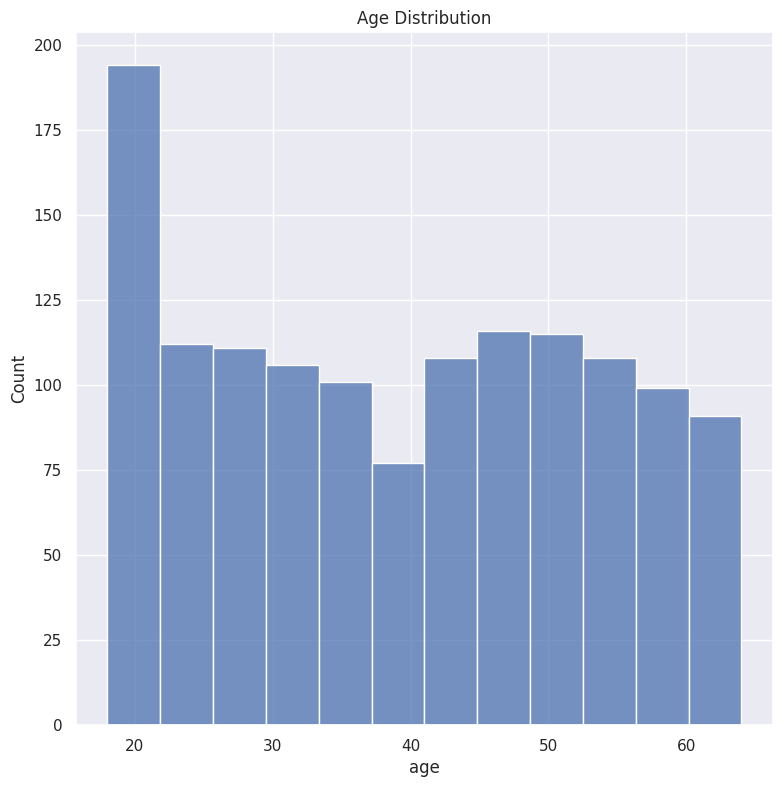

In [15]:
#distributipon of age value
sns.set()
plt.figure(figsize=(9,9))
sns.histplot(insurance_dataset['age'])
plt.title('Age Distribution')

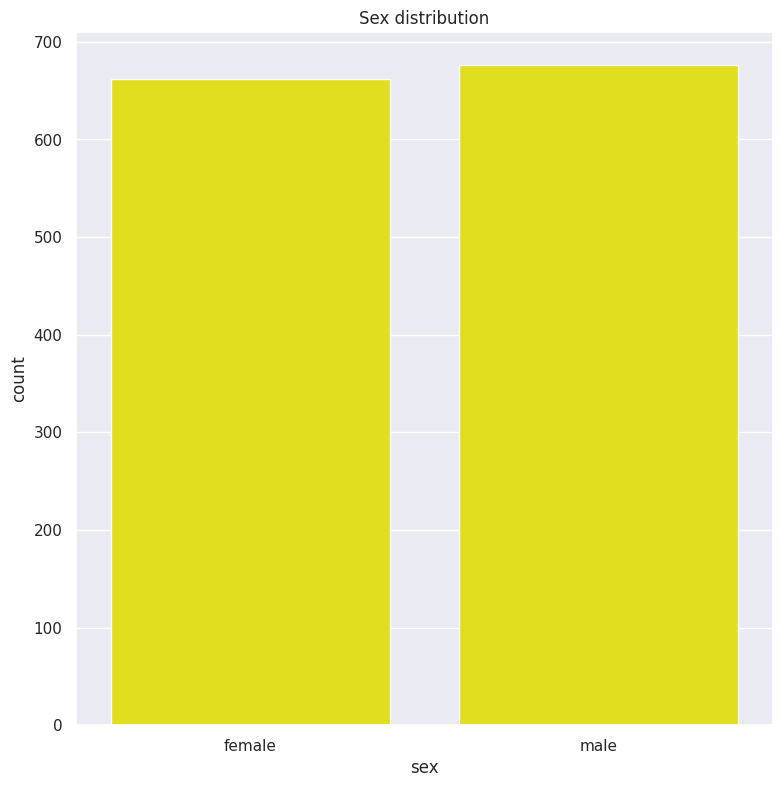

In [16]:
#gender column
plt.figure(figsize=(9,9))
sns.countplot(x='sex',data=insurance_dataset,color="yellow")
plt.title('Sex distribution')
plt.show()

In [17]:
insurance_dataset['sex'].value_counts()

,count
sex,
male,676
female,662


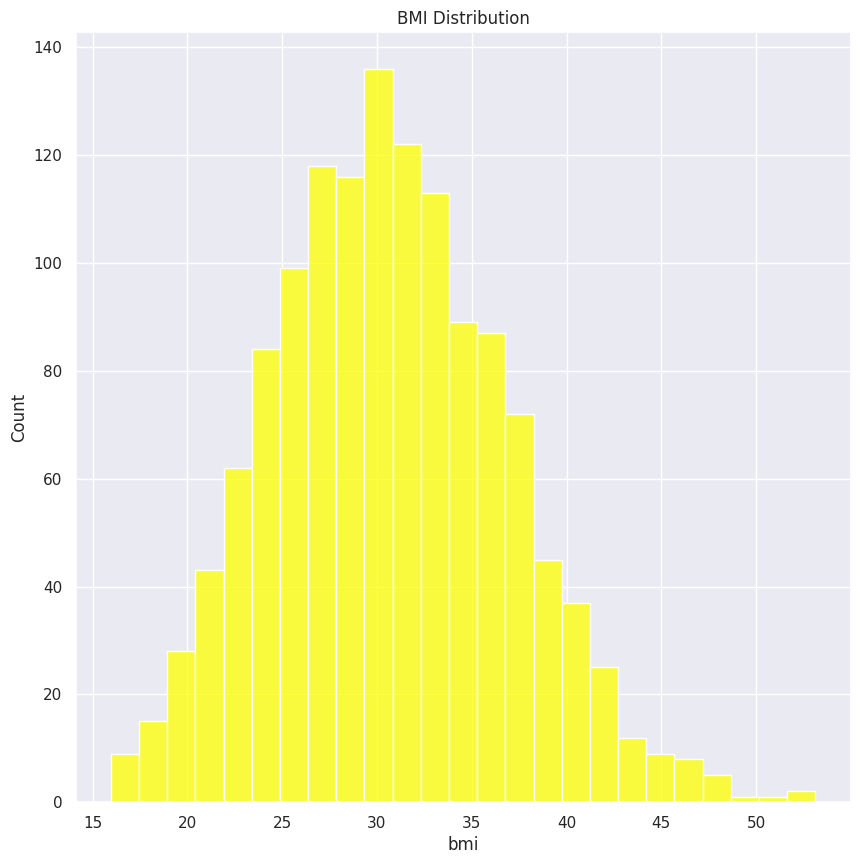

In [18]:
#BMI distribution
plt.figure(figsize=(10,10))
sns.histplot(insurance_dataset['bmi'],color="yellow")
plt.title('BMI Distribution')
plt.show()

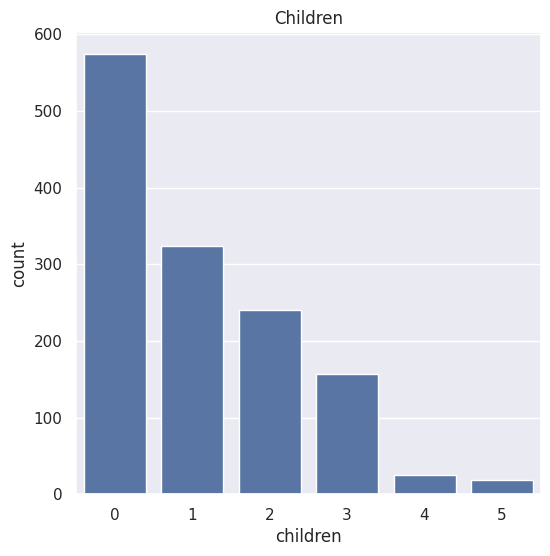

In [19]:
# children column
plt.figure(figsize=(6,6))
sns.countplot(x='children',data=insurance_dataset)
plt.title('Children')
plt.show()



In [20]:
insurance_dataset['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


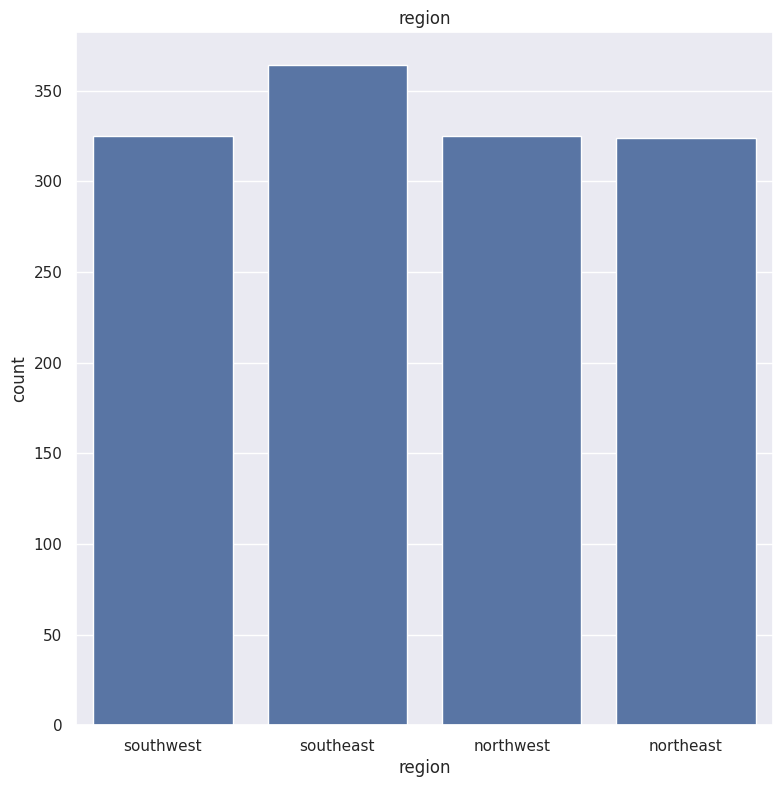

In [21]:
#region column
plt.figure(figsize=(9,9))
sns.countplot(x='region',data=insurance_dataset)
plt.title('region')
plt.show()

In [22]:
insurance_dataset['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


/tmp/ipykernel_4330/2698829632.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['charges'])


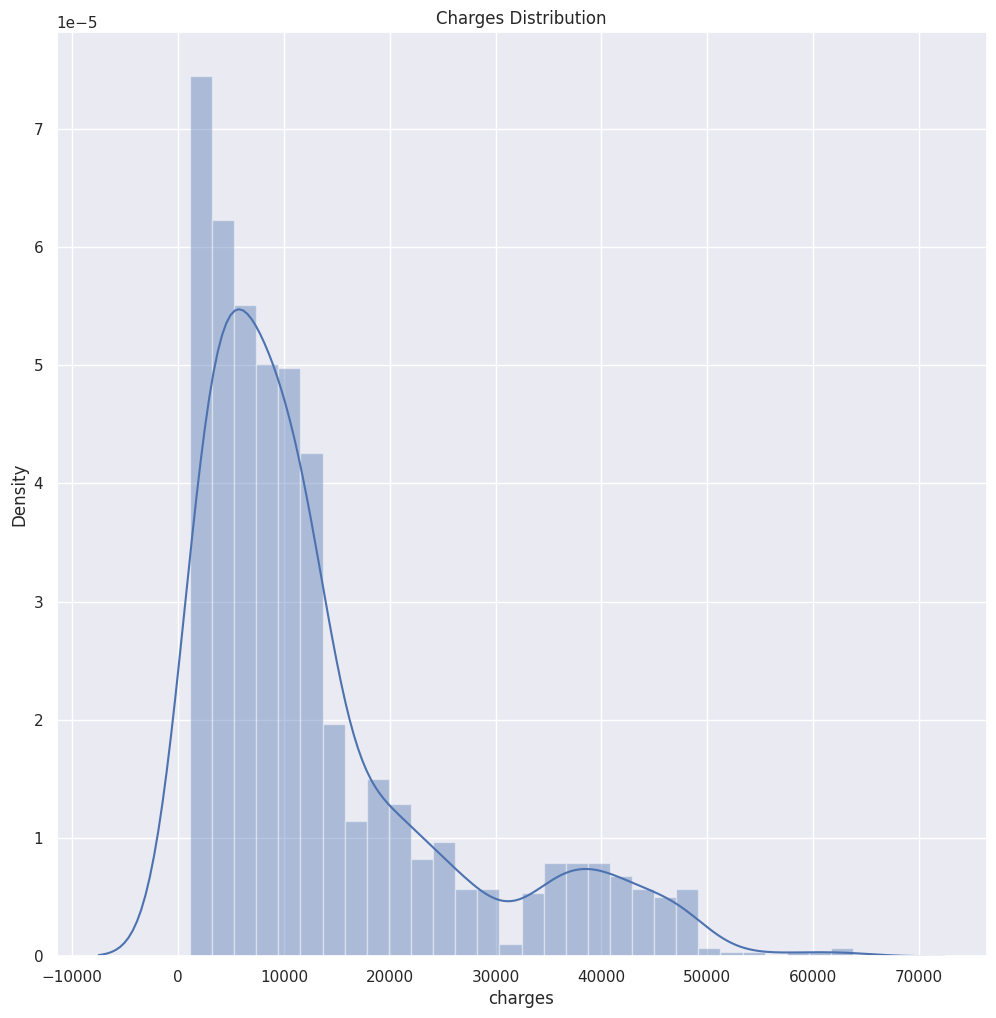

In [23]:
#distribution of charge values
sns.set()
plt.figure(figsize=(12,12))
sns.distplot(insurance_dataset['charges'])
plt.title('Charges Distribution')
plt.show()

In [24]:
#ENCODING THE SEX COLUMN
insurance_dataset.replace({'sex':{'male':0,'female':1}}, inplace=True)
#ENCODING THE smoker COLUMN
insurance_dataset.replace({'smoker':{'yes':0,'no':1}}, inplace=True)
#ENCODING THE Region COLUMN
insurance_dataset.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}}, inplace=True)

/tmp/ipykernel_4330/4271360033.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'sex':{'male':0,'female':1}}, inplace=True)
/tmp/ipykernel_4330/4271360033.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'smoker':{'yes':0,'no':1}}, inplace=True)
/tmp/ipykernel_4330/4271360033.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in

In [25]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520


In [26]:
X=insurance_dataset.drop(columns='charges',axis=1)
Y=insurance_dataset['charges']

In [27]:
print(X)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       0       1
1      18    0  33.770         1       1       0
2      28    0  33.000         3       1       0
3      33    0  22.705         0       1       3
4      32    0  28.880         0       1       3
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       1       3
1334   18    1  31.920         0       1       2
1335   18    1  36.850         0       1       0
1336   21    1  25.800         0       1       1
1337   61    1  29.070         0       0       3

[1338 rows x 6 columns]


In [28]:
print(Y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [29]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [30]:
print(X.shape,X_train.shape,X_test.shape)


(1338, 6) (1070, 6) (268, 6)


In [31]:
model = XGBRegressor(
    n_estimators=300,        # number of trees
    learning_rate=0.05,      # step size
    max_depth=5,             # tree depth
    subsample=0.8,           # row sampling
    colsample_bytree=0.8,    # feature sampling
    random_state=42
)


In [32]:
model.fit(X_train, Y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [33]:
print('Accuracy of XGBoost regressor on training set: {:.2f}'.format(
    model.score(X_train, Y_train)
))

print('Accuracy of XGBoost regressor on testing set: {:.2f}'.format(
    model.score(X_test, Y_test)
))


Accuracy of XGBoost regressor on training set: 0.96
Accuracy of XGBoost regressor on testing set: 0.84


In [34]:
# prediction on training data
training_data_prediction = model.predict(X_train)

# prediction on testing data
test_data_prediction = model.predict(X_test)


In [35]:
input_data = (47,0,25.46,2,1,2)

input_data_as_numpy_array = np.array(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

prediction = model.predict(input_data_reshaped)

print("The insurance cost is Rupees", prediction[0])


The insurance cost is Rupees 10328.822


In [36]:
input_data = (50,0,31.825,0,0,2)

input_data_as_numpy_array = np.array(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

prediction = model.predict(input_data_reshaped)

print("The insurance cost is Rupees", prediction[0])


The insurance cost is Rupees 42031.89


In [37]:
import joblib

joblib.dump(model, "insurance_model.pkl")


['insurance_model.pkl']

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

num_cols = ["age", "bmi", "children"]
cat_cols = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

pipeline.fit(X_train, Y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rou...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [39]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# Re-loading the dataset and preparing variables
try:
    insurance_dataset = pd.read_csv('insurance.csv')
    X = insurance_dataset.drop(columns='charges', axis=1)
    Y = insurance_dataset['charges']
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

    # Defining the pipeline features
    num_cols = ['age', 'bmi', 'children']
    cat_cols = ['sex', 'smoker', 'region']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]
    )

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ))
    ])

    # Fit the pipeline
    pipeline.fit(X_train, Y_train)
    print('Pipeline is trained and ready!')
except FileNotFoundError:
    print("Error: 'insurance.csv' not found. Please re-run the file upload cell.")

Pipeline is trained and ready!


In [40]:
new_data = pd.DataFrame([{
    "age": 18,
    "sex": "female",
    "bmi": 25.08,
    "children": 0,
    "smoker": "no",
    "region": "northeast"
}])

prediction = pipeline.predict(new_data)
print(prediction)


[4689.2285]


In [41]:
!pip install flask pyngrok flask-cors

In [ ]:
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok, conf
import pandas as pd
import os
import time

app = Flask(__name__)
CORS(app)

CSV_FILE = 'collected_data.csv'
STATIC_DOMAIN = "endurable-eternal-yearning.ngrok-free.dev"

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        input_df = pd.DataFrame([data])

        if not os.path.isfile(CSV_FILE):
            input_df.to_csv(CSV_FILE, index=False)
        else:
            input_df.to_csv(CSV_FILE, mode='a', header=False, index=False)

        global pipeline
        prediction = pipeline.predict(input_df)
        return jsonify({'estimated_charges': float(prediction[0])})
    except Exception as e:
        return jsonify({'error': str(e)}), 400

# NGROK CONFIGURATION
NGROK_TOKEN = "3Cg16JKWO8s3BtLFL240WOvazY8_6j8pvx9SSEe9qTmgbHW1u"

def start_ngrok():
    try:
        ngrok.kill()
        time.sleep(2)
        ngrok.set_auth_token(NGROK_TOKEN)

        try:
            print(f"Attempting static domain: {STATIC_DOMAIN}...")
            return ngrok.connect(5000, domain=STATIC_DOMAIN)
        except Exception as e:
            print(f"Static domain failed. Starting ephemeral tunnel...")
            ngrok.kill()
            time.sleep(2)
            return ngrok.connect(5000)
    except Exception as e:
        raise Exception(f"Failed to initialize ngrok: {e}")

try:
    public_url = start_ngrok()
    CURRENT_URL = public_url.public_url

    print(f"\nSUCCESS!")
    print(f"* Public API URL: {CURRENT_URL}")
    print(f"* Data is being saved to: {CSV_FILE}")
    print("\nFlask is starting...")

    app.run(port=5000)
except Exception as e:
    print(f"\nCRITICAL ERROR: {e}")

Attempting static domain: endurable-eternal-yearning.ngrok-free.dev...

SUCCESS!
* Public API URL: https://endurable-eternal-yearning.ngrok-free.dev
* Data is being saved to: collected_data.csv

Flask is starting...
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [22/Apr/2026 04:50:12] "OPTIONS /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Apr/2026 04:50:13] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Apr/2026 04:51:27] "OPTIONS /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Apr/2026 04:51:27] "POST /predict HTTP/1.1" 200 -


In [ ]:
import os
from pyngrok import ngrok

print("Stopping all ngrok tunnels and Flask processes...")

try:
    # 1. Disconnect ngrok tunnels via the library
    tunnels = ngrok.get_tunnels()
    for tunnel in tunnels:
        ngrok.disconnect(tunnel.public_url)
    ngrok.kill()
    print("Successfully killed ngrok.")
except Exception as e:
    print(f"Ngrok already stopped or error: {e}")

# 2. Force kill any python process running Flask on port 5000
# This is the most reliable way to 'stop' a running cell in Colab
os.system("fuser -k 5000/tcp")
print("Port 5000 cleared. You can now run the server cell again.")